In [2]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Charger les données
X_train = np.load('/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/data/X_train.npy')
X_test = np.load('/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/data/X_test.npy')
y_train = np.load('/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/data/y_train.npy')
y_test = np.load('/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/data/y_test.npy')

print(f"Train : {X_train.shape}")
print(f"Test : {X_test.shape}")

Train : (25680, 8)
Test : (6421, 8)


In [3]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred, average='weighted'):.4f}")
print("\n", classification_report(y_test, y_pred, target_names=['Away Win', 'Draw', 'Home Win']))

Accuracy : 0.5227
F1-score : 0.4376

               precision    recall  f1-score   support

    Away Win       0.49      0.37      0.42      1890
        Draw       0.00      0.00      0.00      1488
    Home Win       0.53      0.87      0.66      3043

    accuracy                           0.52      6421
   macro avg       0.34      0.41      0.36      6421
weighted avg       0.40      0.52      0.44      6421



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

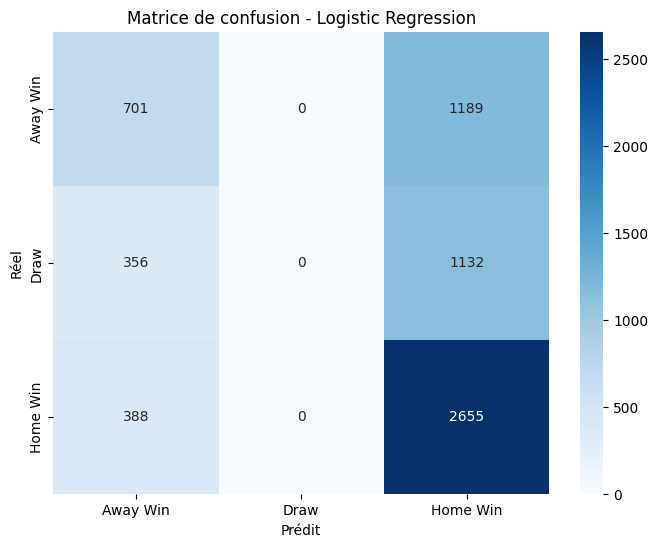

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Matrice de confusion pour la Logistic Regression
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Away Win', 'Draw', 'Home Win'],
            yticklabels=['Away Win', 'Draw', 'Home Win'])
plt.title('Matrice de confusion - Logistic Regression')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

In [5]:
import joblib

# Sauvegarder le modèle
joblib.dump(lr, '/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/models/log_reg.joblib')
print("Modèle sauvegardé ✅")

Modèle sauvegardé ✅


Accuracy : 0.5130
F1-score : 0.4727

               precision    recall  f1-score   support

    Away Win       0.50      0.40      0.45      1890
        Draw       0.25      0.10      0.15      1488
    Home Win       0.55      0.78      0.65      3043

    accuracy                           0.51      6421
   macro avg       0.44      0.43      0.41      6421
weighted avg       0.47      0.51      0.47      6421



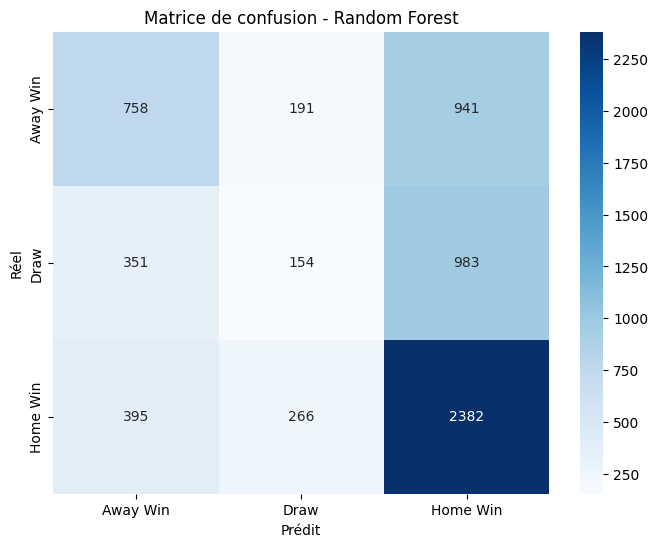

Modèle sauvegardé ✅


In [6]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")
print("\n", classification_report(y_test, y_pred_rf, target_names=['Away Win', 'Draw', 'Home Win']))

# Matrice de confusion
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Away Win', 'Draw', 'Home Win'],
            yticklabels=['Away Win', 'Draw', 'Home Win'])
plt.title('Matrice de confusion - Random Forest')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

# Sauvegarder
joblib.dump(rf, '/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/models/random_forest.joblib')
print("Modèle sauvegardé ✅")

Accuracy : 0.5329
F1-score : 0.4483

               precision    recall  f1-score   support

    Away Win       0.52      0.38      0.44      1890
        Draw       0.20      0.00      0.01      1488
    Home Win       0.54      0.89      0.67      3043

    accuracy                           0.53      6421
   macro avg       0.42      0.42      0.37      6421
weighted avg       0.45      0.53      0.45      6421



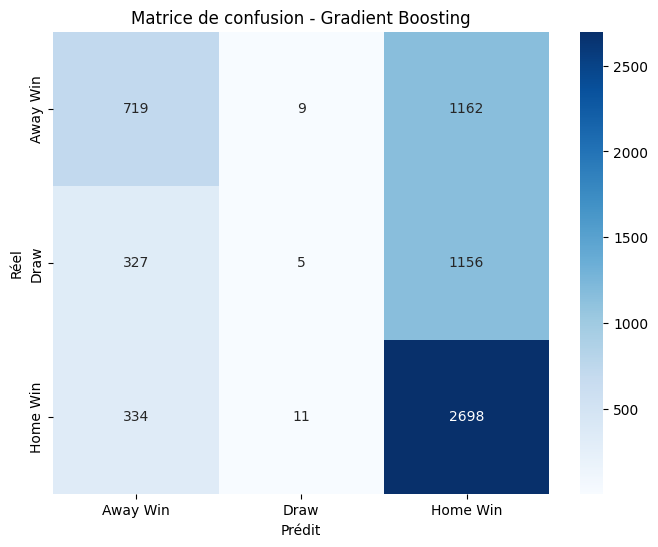

Modèle sauvegardé ✅


In [7]:
from sklearn.ensemble import GradientBoostingClassifier

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_gb, average='weighted'):.4f}")
print("\n", classification_report(y_test, y_pred_gb, target_names=['Away Win', 'Draw', 'Home Win']))

# Matrice de confusion
cm_gb = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(8,6))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Away Win', 'Draw', 'Home Win'],
            yticklabels=['Away Win', 'Draw', 'Home Win'])
plt.title('Matrice de confusion - Gradient Boosting')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

# Sauvegarder
joblib.dump(gb, '/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/models/gradient_boosting.joblib')
print("Modèle sauvegardé ✅")

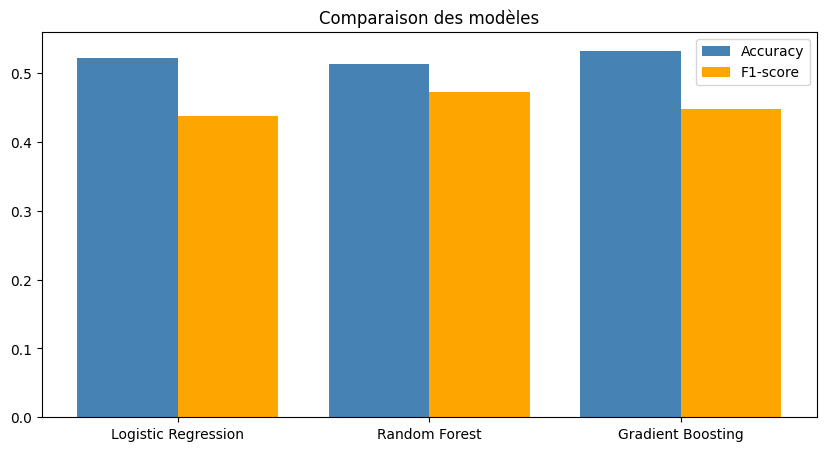

In [8]:
# Comparaison des modèles
models = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']
accuracies = [0.5227, 0.5130, 0.5329]
f1_scores = [0.4376, 0.4727, 0.4483]

x = range(len(models))
plt.figure(figsize=(10,5))
plt.bar([i - 0.2 for i in x], accuracies, width=0.4, label='Accuracy', color='steelblue')
plt.bar([i + 0.2 for i in x], f1_scores, width=0.4, label='F1-score', color='orange')
plt.xticks(x, models)
plt.title('Comparaison des modèles')
plt.legend()
plt.show()

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import joblib

# 1. Logistic Regression optimisée
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print(f"LR - Accuracy: {accuracy_score(y_test, y_pred_lr):.4f} | F1: {f1_score(y_test, y_pred_lr, average='weighted'):.4f}")
joblib.dump(lr, '/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/models/log_reg.joblib')

# 2. Random Forest optimisé
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f"RF - Accuracy: {accuracy_score(y_test, y_pred_rf):.4f} | F1: {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")
joblib.dump(rf, '/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/models/random_forest.joblib')

# 3. Gradient Boosting optimisé
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print(f"GB - Accuracy: {accuracy_score(y_test, y_pred_gb):.4f} | F1: {f1_score(y_test, y_pred_gb, average='weighted'):.4f}")
joblib.dump(gb, '/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/models/gradient_boosting.joblib')

LR - Accuracy: 0.4854 | F1: 0.4811
RF - Accuracy: 0.5143 | F1: 0.4685
GB - Accuracy: 0.5407 | F1: 0.4624


['/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/models/gradient_boosting.joblib']

In [10]:
import numpy as np
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Recharger les données
X_train = np.load('/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/data/X_train.npy')
X_test = np.load('/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/data/X_test.npy')
y_train = np.load('/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/data/y_train.npy')
y_test = np.load('/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/data/y_test.npy')

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print(f"LR  - Accuracy: {accuracy_score(y_test, y_pred_lr):.4f} | F1 macro: {f1_score(y_test, y_pred_lr, average='macro'):.4f}")
joblib.dump(lr, '/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/models/log_reg.joblib')

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f"RF  - Accuracy: {accuracy_score(y_test, y_pred_rf):.4f} | F1 macro: {f1_score(y_test, y_pred_rf, average='macro'):.4f}")
joblib.dump(rf, '/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/models/random_forest.joblib')

# 3. Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print(f"GB  - Accuracy: {accuracy_score(y_test, y_pred_gb):.4f} | F1 macro: {f1_score(y_test, y_pred_gb, average='macro'):.4f}")
joblib.dump(gb, '/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/models/gradient_boosting.joblib')

print("\nTous les modèles sauvegardés ✅")

LR  - Accuracy: 0.5027 | F1 macro: 0.4630
RF  - Accuracy: 0.5326 | F1 macro: 0.4321
GB  - Accuracy: 0.5523 | F1 macro: 0.4161

Tous les modèles sauvegardés ✅


In [11]:
from imblearn.over_sampling import SMOTE

# Rééquilibrer les classes avec SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Avant SMOTE : {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Après SMOTE : {dict(zip(*np.unique(y_train_smote, return_counts=True)))}")

Avant SMOTE : {np.int64(0): np.int64(7109), np.int64(1): np.int64(6066), np.int64(2): np.int64(12505)}
Après SMOTE : {np.int64(0): np.int64(12505), np.int64(1): np.int64(12505), np.int64(2): np.int64(12505)}


In [12]:
# 1. Logistic Regression avec SMOTE
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)
y_pred_lr = lr_smote.predict(X_test)
print(f"LR  - Accuracy: {accuracy_score(y_test, y_pred_lr):.4f} | F1 macro: {f1_score(y_test, y_pred_lr, average='macro'):.4f}")
joblib.dump(lr_smote, '/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/models/log_reg.joblib')

# 2. Random Forest avec SMOTE
rf_smote = RandomForestClassifier(n_estimators=200, random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_rf = rf_smote.predict(X_test)
print(f"RF  - Accuracy: {accuracy_score(y_test, y_pred_rf):.4f} | F1 macro: {f1_score(y_test, y_pred_rf, average='macro'):.4f}")
joblib.dump(rf_smote, '/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/models/random_forest.joblib')

# 3. Gradient Boosting avec SMOTE
gb_smote = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
gb_smote.fit(X_train_smote, y_train_smote)
y_pred_gb = gb_smote.predict(X_test)
print(f"GB  - Accuracy: {accuracy_score(y_test, y_pred_gb):.4f} | F1 macro: {f1_score(y_test, y_pred_gb, average='macro'):.4f}")
joblib.dump(gb_smote, '/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/models/gradient_boosting.joblib')

print("\nTous les modèles sauvegardés ✅")

LR  - Accuracy: 0.5029 | F1 macro: 0.4621
RF  - Accuracy: 0.5111 | F1 macro: 0.4487
GB  - Accuracy: 0.5364 | F1 macro: 0.4448

Tous les modèles sauvegardés ✅


In [13]:
# Recharger les données
X_train = np.load('/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/data/X_train.npy')
X_test = np.load('/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/data/X_test.npy')
y_train = np.load('/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/data/y_train.npy')
y_test = np.load('/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/data/y_test.npy')

# SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_smote, y_train_smote)
y_pred_lr = lr.predict(X_test)
print(f"LR - Accuracy: {accuracy_score(y_test, y_pred_lr):.4f} | F1 macro: {f1_score(y_test, y_pred_lr, average='macro'):.4f}")
joblib.dump(lr, '/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/models/log_reg.joblib')

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_smote, y_train_smote)
y_pred_rf = rf.predict(X_test)
print(f"RF - Accuracy: {accuracy_score(y_test, y_pred_rf):.4f} | F1 macro: {f1_score(y_test, y_pred_rf, average='macro'):.4f}")
joblib.dump(rf, '/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/models/random_forest.joblib')

# 3. Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
gb.fit(X_train_smote, y_train_smote)
y_pred_gb = gb.predict(X_test)
print(f"GB - Accuracy: {accuracy_score(y_test, y_pred_gb):.4f} | F1 macro: {f1_score(y_test, y_pred_gb, average='macro'):.4f}")
joblib.dump(gb, '/Users/maximiliendorn/Desktop/ACheving/ml-poc-project/models/gradient_boosting.joblib')

print("\nTous les modèles sauvegardés ✅")

LR - Accuracy: 0.5300 | F1 macro: 0.4911
RF - Accuracy: 0.5507 | F1 macro: 0.4864
GB - Accuracy: 0.5653 | F1 macro: 0.4777

Tous les modèles sauvegardés ✅
